# 03 — Unsupervised Clustering of MMS Plasma Regions via PCA

**Purpose:** Reduce high-dimensional MMS ion spectra to their principal components, apply three clustering algorithms, and compare their recovered structure against known plasma-region labels.

> This notebook follows directly from *02 – Data Exploration*. The `log10p1` preprocessing established in notebook 02 is used throughout — make sure you have run (or are familiar with) notebook 02 before starting here.

## Learning Objectives

By the end of this notebook you will be able to:

- Split a labelled dataset into train and test sets **without leaking information** between them.
- Fit a PCA model on the training set and apply it to held-out data.
- Run and compare three clustering algorithms (K-Means, GMM, Agglomerative) on the reduced feature space.
- Quantify clustering quality with Adjusted Rand Index (ARI) and Normalised Mutual Information (NMI), and interpret what these numbers mean for plasma region identification.
- Use the Hungarian algorithm to optimally match cluster IDs to physical region labels, and read a confusion matrix.

## 1 · Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap

from spacephyml.datasets.mms import SpectrumDataset
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, confusion_matrix, adjusted_mutual_info_score
from scipy.optimize import linear_sum_assignment

from pathlib import Path

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

figure_path = Path('./figures')
figure_path.mkdir(exist_ok=True)

RANDOM_STATE = 42
NC_FILE = 'data/data_cleaned.nc'

REGION_NAMES  = {0: 'Solar Wind', 1: 'Ion Foreshock', 2: 'Magnetosheath', 3: 'Magnetosphere'}
REGION_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
PALETTE       = dict(zip(REGION_NAMES.values(), REGION_COLORS))

## 2 · Preprocessing

As established in notebook 02, ion flux spans ~8 decades of dynamic range. Feeding raw counts into PCA would let the highest-flux regions (Solar Wind, Ion Foreshock, Magnetosheath, all peaking near 10⁸) dominate every principal component, while the Magnetosphere (~10⁶) would barely register.

We use `log10p1` — i.e. `log₁₀(1 + x)` — applied globally. This maps the full flux range to a compact [0, ~8] interval while preserving the spectral shape: the ratio of intensities across energy channels is unchanged, so the patterns that distinguish the four regions are intact. Per-feature standardisation is deliberately avoided for this reason.

In [2]:
def preprocess(X: np.ndarray) -> np.ndarray:
    """Apply log₁₀(1 + x) scaling to a (samples, features) flux array.

    Global transform: the spectral shape (relative intensity across energy
    channels) is preserved. Maps the ~8-decade flux range to [0, ~8].
    """
    return np.log10(1. + X)

# Quick sanity check
import numpy as _np
_x = _np.array([0, 10, 1e4, 1e6, 1e8])
print("log10p1 of [0, 10, 1e4, 1e6, 1e8]:", preprocess(_x).round(2))

log10p1 of [0, 10, 1e4, 1e6, 1e8]: [0.   1.04 4.   6.   8.  ]


## 3 · Load the Dataset

We load a **balanced** dataset — the same number of windows per plasma region — to prevent the majority class from dominating the unsupervised algorithms. Each window is flattened into a 1-D feature vector of length `N × n_energy_bins`.

In [3]:
N = 66          # ≈ 5 minutes at 4.5 s cadence
SAMPLES = 529    # windows per class (balanced)

ds = SpectrumDataset(
    dataset_path=NC_FILE,
    N=N,
    samples=SAMPLES,
    flatten=True,
    fill_unknown=True, #Allow some "unknown" labels in windows if surronding labels are the same
)

X_raw, y_tensor = ds[:]
X_raw = X_raw.numpy()
y     = y_tensor.numpy()

print(f"\nDataset shape : {X_raw.shape}  ({X_raw.shape[0]} samples × {X_raw.shape[1]} features)")
print(f"Class counts  : { {REGION_NAMES[k]: int(v) for k,v in zip(*np.unique(y, return_counts=True))} }")

Max number of samples per classification is: 529

Dataset shape : (2116, 2112)  (2116 samples × 2112 features)
Class counts  : {'Solar Wind': 529, 'Ion Foreshock': 529, 'Magnetosheath': 529, 'Magnetosphere': 529}


## 4 · Train / Test Split

We split **before** any preprocessing or PCA. This is critical: fitting the preprocessor or the PCA on the test set would constitute **data leakage** — the model would have indirect access to test-set information during training, inflating apparent performance.

`stratify=y` ensures both splits maintain the same class proportions.

In [4]:
TEST_SIZE = 0.30

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set : {X_train_raw.shape[0]:,} samples")
print(f"Test set     : {X_test_raw.shape[0]:,} samples")

for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"\n{split_name} proportions:")
    for label, frac in zip(unique, counts / counts.sum()):
        print(f"  {REGION_NAMES[label]:<20} {frac:.1%}")

Training set : 1,481 samples
Test set     : 635 samples

Train proportions:
  Solar Wind           25.0%
  Ion Foreshock        25.1%
  Magnetosheath        25.0%
  Magnetosphere        25.0%

Test proportions:
  Solar Wind           25.0%
  Ion Foreshock        24.9%
  Magnetosheath        25.0%
  Magnetosphere        25.0%


## 5 · Apply Preprocessing

`log10p1` has no fitted parameters — the same formula is applied to both splits identically. We call it separately on train and test to make the pattern explicit and keep it consistent with pipelines where the preprocessor *does* have fitted parameters (e.g. `minmax` with percentile bounds computed from training data).

In [5]:
X_train = preprocess(X_train_raw)
X_test  = preprocess(X_test_raw)

print(f"Flux range after preprocessing — train: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Flux range after preprocessing — test:  [{X_test.min():.3f}, {X_test.max():.3f}]")

Flux range after preprocessing — train: [0.000, 8.241]
Flux range after preprocessing — test:  [0.000, 8.251]


## 6 · PCA Reduction

### Why reduce before clustering?

Clustering algorithms struggle in high-dimensional spaces. In many dimensions, points become almost equidistant from each other — the so-called *curse of dimensionality* — making it hard for algorithms like K-Means (which relies on Euclidean distance) to find meaningful structure. PCA concentrates most of the variance into a handful of components, giving the clusterers a lower-dimensional space where distances are more informative.

### Fit on train, transform both

Just like the preprocessor, the PCA must be **fitted only on the training set**. We then apply the same projection (the same eigenvectors) to the test set. Using `N_PCS = 8` retains the dominant structure identified in notebook 02 while discarding noisy higher components.

In [6]:
N_PCS = 8   # components to keep; see notebook 02 scree plot for justification

pca = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
pca.fit(X_train)

evr      = pca.explained_variance_ratio_
cum_evr  = np.cumsum(evr)

X_train_pca = pca.transform(X_train)[:, :N_PCS]
X_test_pca  = pca.transform(X_test) [:, :N_PCS]

print(f"Shape after PCA reduction — Train: {X_train_pca.shape}, Test: {X_test_pca.shape}")
print(f"Variance retained by top {N_PCS} PCs: {cum_evr[N_PCS-1]*100:.1f}%")

Shape after PCA reduction — Train: (1481, 8), Test: (635, 8)
Variance retained by top 8 PCs: 63.5%


## 7 · Clustering on the Top PCs

We test three algorithms with complementary assumptions:

| Algorithm | Shape assumption | Handles overlap? | Notes |
|-----------|----------------|-----------------|-------|
| **K-Means** | Spherical, equal-size clusters | No — hard assignment | Fast; sensitive to outliers |
| **GMM** | Elliptical Gaussians | Yes — soft probabilities | More flexible; used in Toy-Edens et al. (2024) |
| **Agglomerative** | Hierarchical merging | No — hard assignment | No `predict()` for new data |

For all three we set `n_clusters = 4` because we know there are four physical regions. **Clustering is unsupervised — labels are never used during fitting**, only afterwards to score the result.

### 7.1 · Fit the clusterers

In [7]:
N_CLUSTERS = 4

# ── K-Means ───────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, max_iter=500, random_state=RANDOM_STATE)
kmeans.fit(X_train_pca)

# ── Gaussian Mixture Model ────────────────────────────────────────────────
# covariance_type='full' allows each cluster its own ellipsoidal shape
gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      n_init=5, max_iter=300, random_state=RANDOM_STATE)
gmm.fit(X_train_pca)

# ── Agglomerative Clustering ──────────────────────────────────────────────
# No out-of-sample predict() — fit on the full dataset and split afterwards
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
all_pca        = np.vstack([X_train_pca, X_test_pca])
agg_labels_all = agg.fit_predict(all_pca)
agg_train      = agg_labels_all[:len(X_train_pca)]
agg_test       = agg_labels_all[len(X_train_pca):]

print("Clustering complete.")

Clustering complete.


### 7.2 · Collect test-set predictions

In [8]:
predictions = {
    'K-Means'       : kmeans.predict(X_test_pca),
    'GMM'           : gmm.predict(X_test_pca),
    'Agglomerative' : agg_test,
}

## 8 · Quantitative Comparison Against Ground-Truth Labels

Clustering produces *cluster IDs*, not region names — cluster 0 might correspond to the magnetosheath, or it might not. Two metrics sidestep the label-matching problem entirely:

- **Adjusted Rand Index (ARI):** measures agreement between two partitions, corrected for chance. Range: ≤ 0 (no better than random) → 1 (perfect).
- **Adjusted Mutual Information (AMI)**: measures how much knowing the cluster assignment reduces uncertainty about the true label, corrected for chance so random clusterings score near 0. Range: −1 → 1.

For the confusion matrix we *do* need to match cluster IDs to region labels. Here we use majority vote i.e. if the majoryt of a cluster belongs to that label we assign the cluster to that label. An alterntive to majority vote is the **Hungarian algorithm** which finds the optimal one-to-one assignment by maximising overlap.

In [9]:
def hungarian_match(y_true, y_pred):
    """Remap cluster IDs to best-matching true labels via the Hungarian algorithm."""
    cost_matrix = -confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {pred: true for true, pred in zip(row_ind, col_ind)}
    return np.array([mapping.get(p, -1) for p in y_pred])
    
def majority_vote_match(y_true, y_pred):
    """Remap cluster IDs to best-matching true labels via majority vote."""
    cm = confusion_matrix(y_true, y_pred)
    mapping = {pred: true for pred, true in enumerate(cm.argmax(axis=0))}
    return np.array([mapping.get(p, -1) for p in y_pred])

results  = []
remapped = {}

for name, y_pred in predictions.items():
    ari = adjusted_rand_score(y_test, y_pred)
    ami = adjusted_mutual_info_score(y_test, y_pred)
    results.append({'Model': name, 'Clusters': len(set(y_pred)),
                    'ARI': round(ari, 3), 'AMI': round(ami, 3)})
    remapped[name] = majority_vote_match(y_test, y_pred)

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

               Clusters    ARI    AMI
Model                                
K-Means               4  0.699  0.707
GMM                   4  0.853  0.860
Agglomerative         4  0.745  0.767


## 9 · Confusion Matrices

After optimal label matching, a confusion matrix shows for each true region how the clusterer distributed those observations across its predicted labels. The diagonal is correct assignments; off-diagonal entries reveal systematic confusions.

Pay attention to the **Solar Wind / Ion Foreshock** pair — both have a narrow, high-energy spectral peak, so some confusion is physically expected.

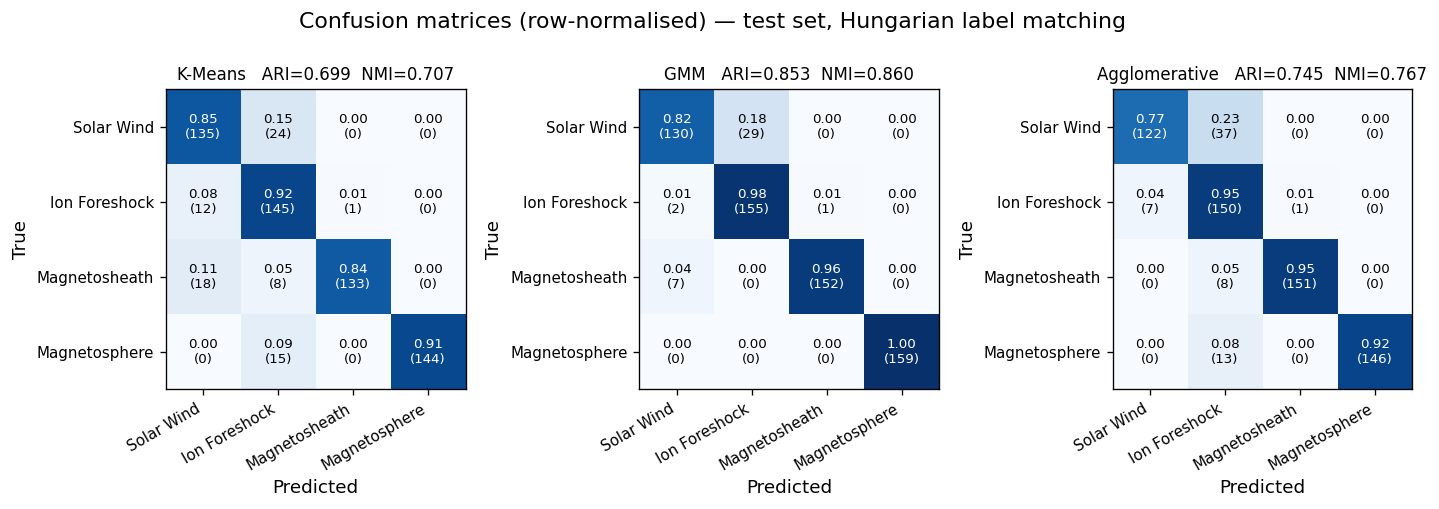

In [10]:
region_labels = list(REGION_NAMES.values())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, y_remapped) in zip(axes, remapped.items()):
    cm      = confusion_matrix(y_test, y_remapped, labels=list(range(N_CLUSTERS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax.imshow(cm_norm, vmin=0, vmax=1, cmap='Blues')
    for i in range(N_CLUSTERS):
        for j in range(N_CLUSTERS):
            color = 'white' if cm_norm[i, j] > 0.6 else 'black'
            ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]:,})",
                    ha='center', va='center', fontsize=8, color=color)

    ax.set_xticks(range(N_CLUSTERS)); ax.set_yticks(range(N_CLUSTERS))
    ax.set_xticklabels(region_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(region_labels, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

    ari = results_df.loc[name, 'ARI']
    nmi = results_df.loc[name, 'AMI']
    ax.set_title(f"{name}   ARI={ari:.3f}  NMI={nmi:.3f}", fontsize=10)

plt.suptitle("Confusion matrices (row-normalised) — test set, Hungarian label matching", y=1.02)
plt.tight_layout()
plt.savefig(figure_path / '03_clustering_confusion_matrix.png', bbox_inches='tight')

## 10 · Cluster Assignments in PC1–PC2 Space

Projecting onto the first two PCs lets us visually compare where the algorithms place their cluster boundaries versus the ground-truth labels. Points are subsampled for plotting speed.

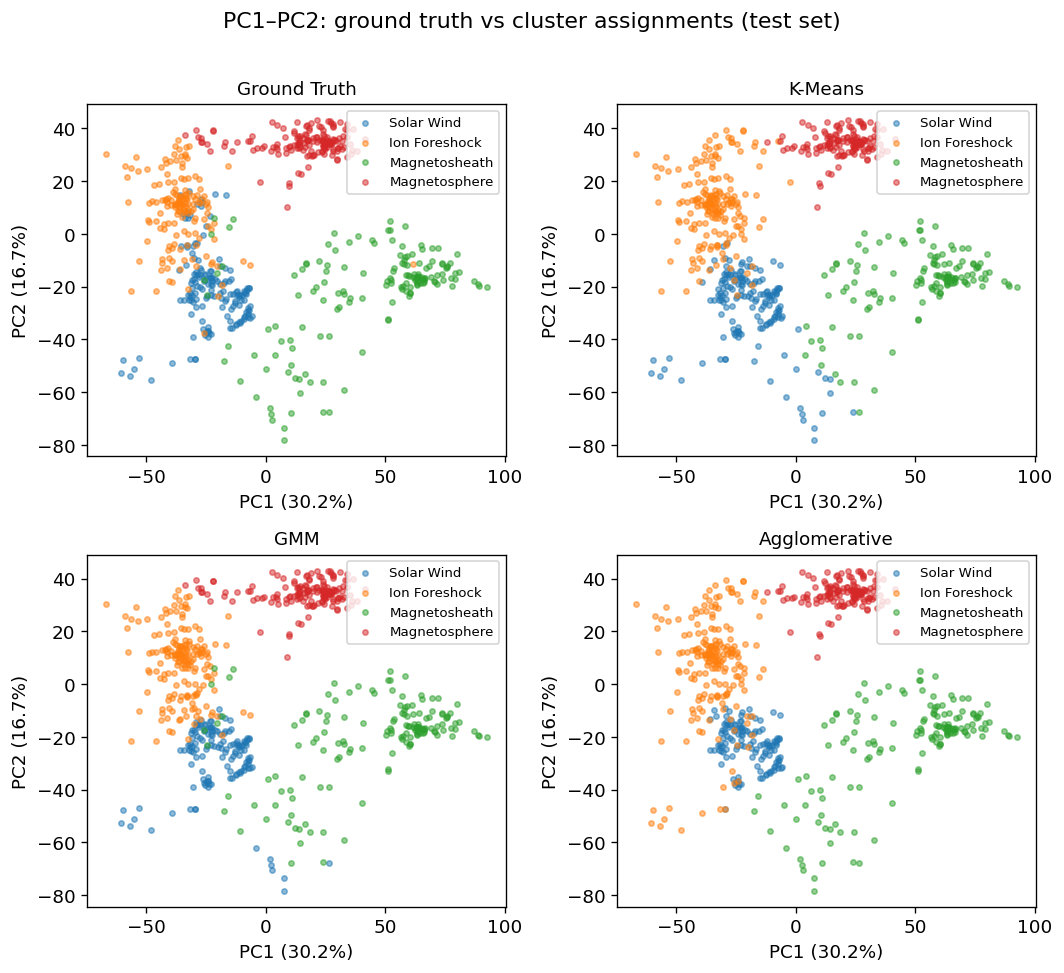

In [11]:
rng      = np.random.default_rng(RANDOM_STATE)
plot_idx = rng.choice(len(X_test_pca), size=min(2000, len(X_test_pca)), replace=False)

all_panels = [('Ground Truth', y_test)] + list(remapped.items())
fig, axes  = plt.subplots(2, 2, figsize=(9, 8))

for ax, (title, labels) in zip(axes.flat, all_panels):
    sub_labels = labels[plot_idx]
    sub_pca    = X_test_pca[plot_idx]
    for label, (name, color) in enumerate(zip(REGION_NAMES.values(), REGION_COLORS)):
        mask = sub_labels == label
        if mask.any():
            ax.scatter(sub_pca[mask, 0], sub_pca[mask, 1],
                       s=10, alpha=0.5, color=color, label=name)
    ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=1, fontsize=8, loc='upper right')

plt.suptitle("PC1–PC2: ground truth vs cluster assignments (test set)", y=1.01)
plt.tight_layout()
plt.savefig(figure_path / '03_PC1-2_cluster_label_comparison.png', bbox_inches='tight')

## 11 · Summary Comparison

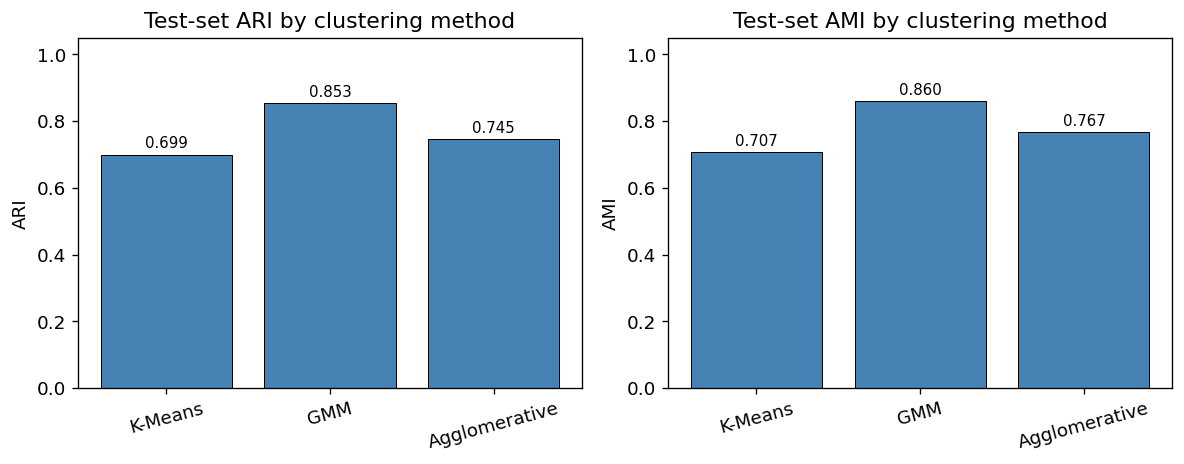

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric in zip(axes, ['ARI', 'AMI']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals, color='steelblue', edgecolor='k', linewidth=0.6)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.set_title(f"Test-set {metric} by clustering method")
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(figure_path / '03_cluster_label_agreement.png', bbox_inches='tight')

## Summary

**What we did:**

- Loaded a balanced MMS dataset and applied `log10p1` scaling (`log₁₀(1 + x)`) from notebook 02 — a global transform that compresses the ~8-decade flux range while preserving the spectral shape across energy channels.
- Split into train (70%) and test (30%) sets **before** any fitting, with stratification to preserve class balance.
- Fitted PCA on the training set only and projected both sets onto the top 8 components, retaining the dominant spectral variance.
- Applied K-Means, GMM, and Agglomerative clustering to the 8-dimensional PC space — with **no label information** during fitting.
- Compared all three methods against ground-truth region labels using ARI, NMI, and optimally-matched confusion matrices.

**Key takeaways:**

1. **Fit-transform discipline matters.** Fitting the preprocessor or PCA on the test set leaks information and inflates apparent performance — always fit on train, transform both.
2. **GMM tends to outperform K-Means** on plasma data because the regions form ellipsoidal, overlapping distributions in feature space, not spherical ones — consistent with Toy-Edens et al. (2024).
3. **Clustering ≠ labelling.** ARI and NMI avoid the permutation problem; the Hungarian algorithm is needed before computing a meaningful confusion matrix.
4. **PCA compresses but also loses.** More PCs help up to a point; beyond that, you add noise dimensions that hurt cluster separation.
5. **Physical interpretability:** Solar Wind and Ion Foreshock are the most commonly confused pair — both have narrow high-energy spectral peaks, so this is physically expected rather than a modelling failure.

**Further reading:**

- Toy-Edens et al. (2024), *JGR Space Physics* — GMM clustering of 8 years of MMS data
- Bakrania et al. (2020), *Front. Astron. Space Sci.* — dimensionality reduction and clustering for space plasma regimes
- scikit-learn: [Clustering](https://scikit-learn.org/stable/modules/clustering.html), [Decomposition](https://scikit-learn.org/stable/modules/decomposition.html)